In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
#https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package  #Dataset link
weather_df = pd.read_csv('weatherAUS.csv')
weather_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


# EDA

In [3]:
weather_df.shape

(145460, 23)

In [4]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [5]:
weather_df.dropna(subset=['RainToday', 'RainTomorrow'],inplace=True)

In [6]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140787 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           140787 non-null  object 
 1   Location       140787 non-null  object 
 2   MinTemp        140319 non-null  float64
 3   MaxTemp        140480 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81093 non-null   float64
 6   Sunshine       73982 non-null   float64
 7   WindGustDir    131624 non-null  object 
 8   WindGustSpeed  131682 non-null  float64
 9   WindDir9am     131127 non-null  object 
 10  WindDir3pm     137117 non-null  object 
 11  WindSpeed9am   139732 non-null  float64
 12  WindSpeed3pm   138256 non-null  float64
 13  Humidity9am    139270 non-null  float64
 14  Humidity3pm    137286 non-null  float64
 15  Pressure9am    127044 non-null  float64
 16  Pressure3pm    127018 non-null  float64
 17  Cloud9am       88162 non-null   fl

In [7]:
weather_df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,140319.000000,140480.00000,140787.000000,81093.000000,73982.000000,131682.000000,139732.000000,138256.000000,139270.000000,137286.000000,127044.000000,127018.000000,88162.000000,84693.000000,140131.000000,138163.000000
mean,12.184824,23.23512,2.349974,5.472516,7.630540,39.970520,13.990496,18.631141,68.826833,51.449288,1017.654577,1015.257963,4.431161,4.499250,16.987066,21.693183
std,6.403879,7.11450,8.465173,4.189132,3.781729,13.578201,8.886210,8.798096,19.063650,20.807310,7.104867,7.035411,2.886594,2.719752,6.496012,6.937784
min,-8.500000,-4.80000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000
25%,7.600000,17.90000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.000000,1010.400000,1.000000,2.000000,12.300000,16.600000
50%,12.000000,22.60000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000
75%,16.800000,28.30000,0.800000,7.400000,10.700000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000
max,33.900000,48.10000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000


In [8]:
num_cols = weather_df.select_dtypes(np.number).columns.to_list()
num_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm']

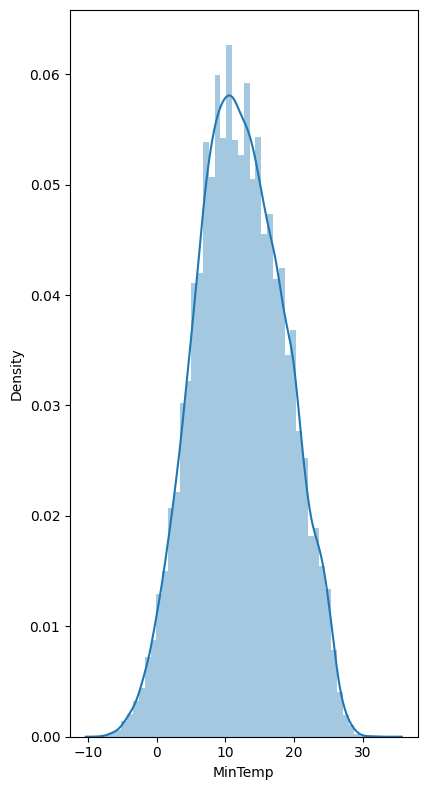

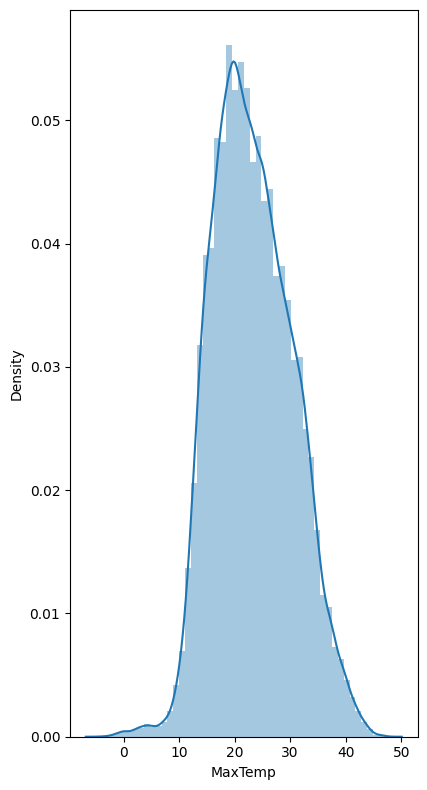

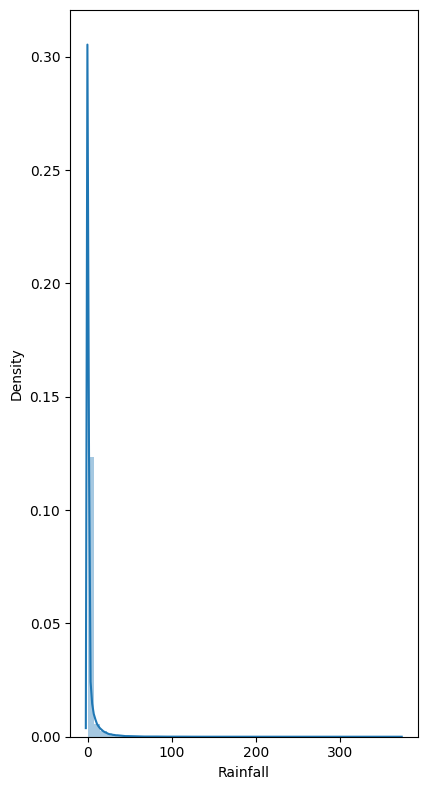

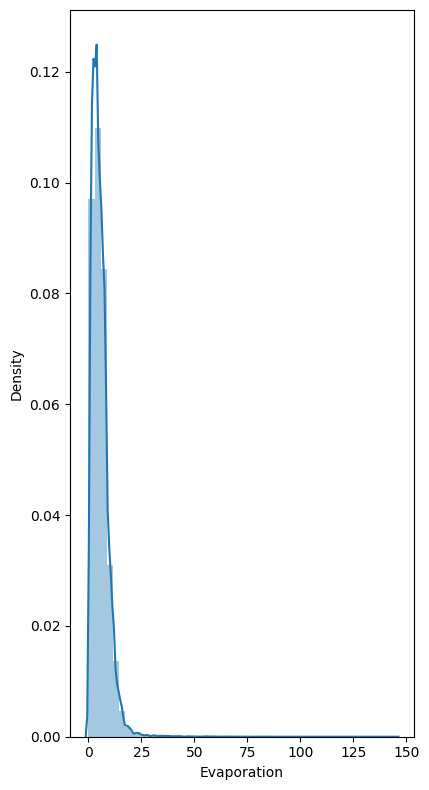

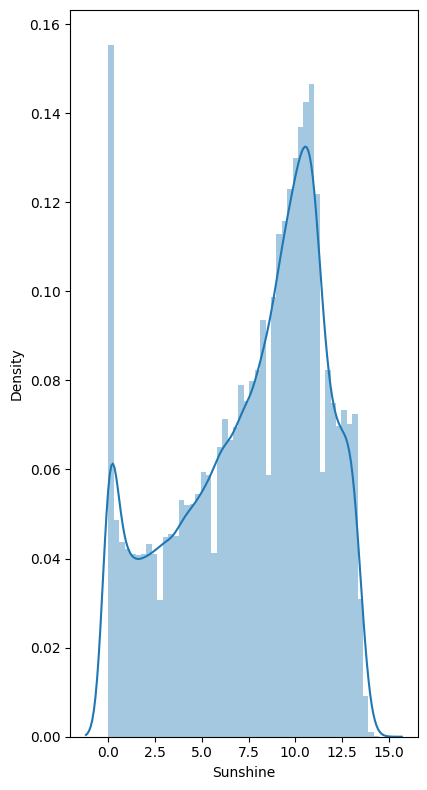

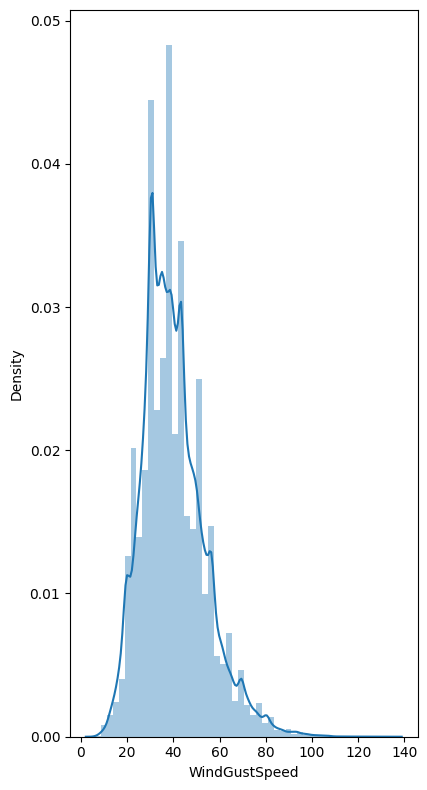

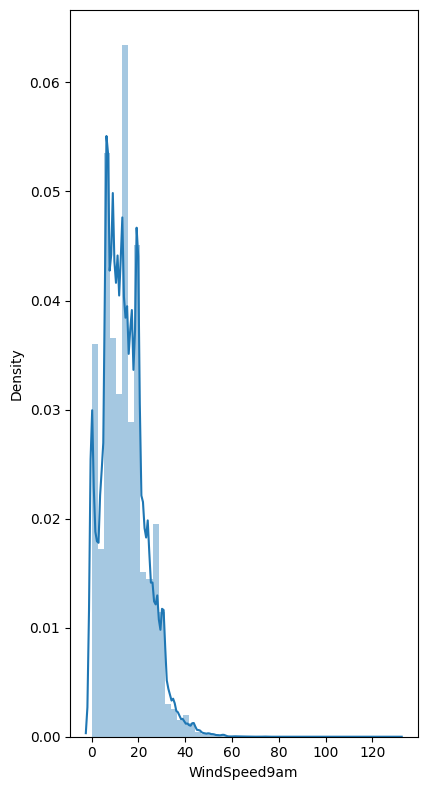

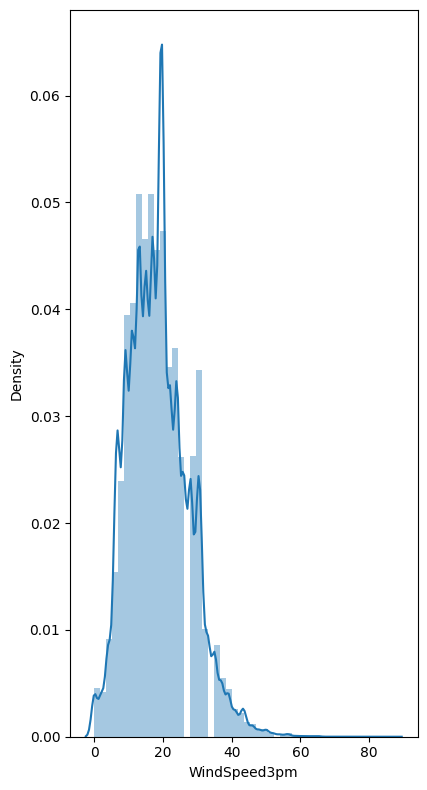

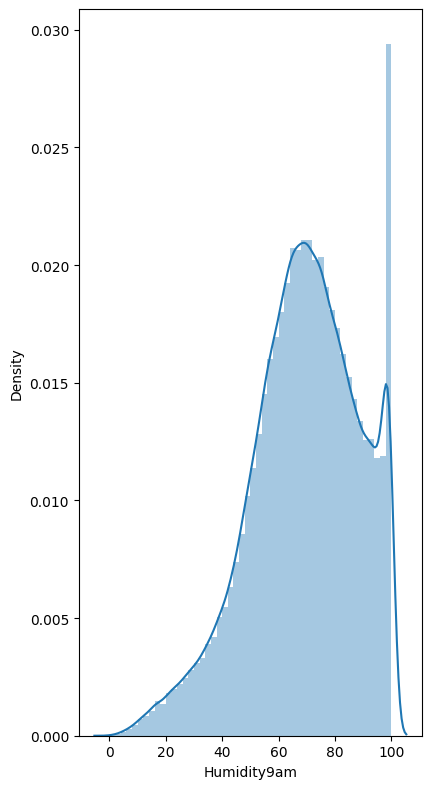

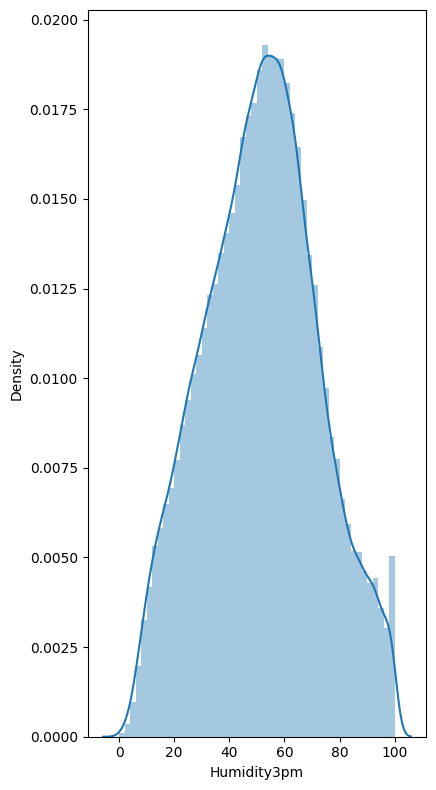

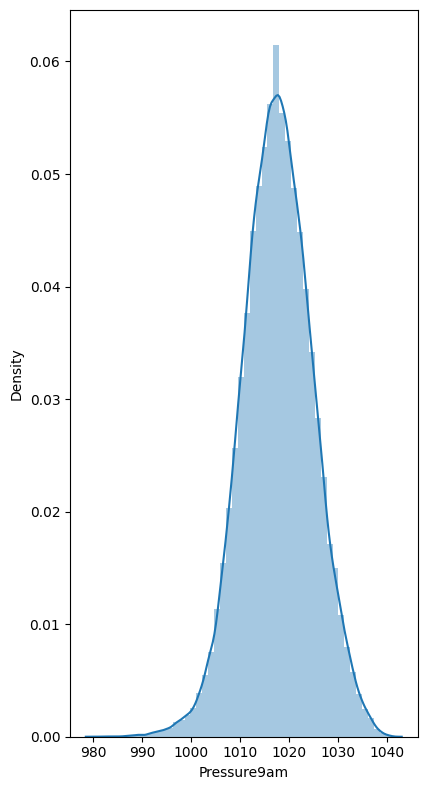

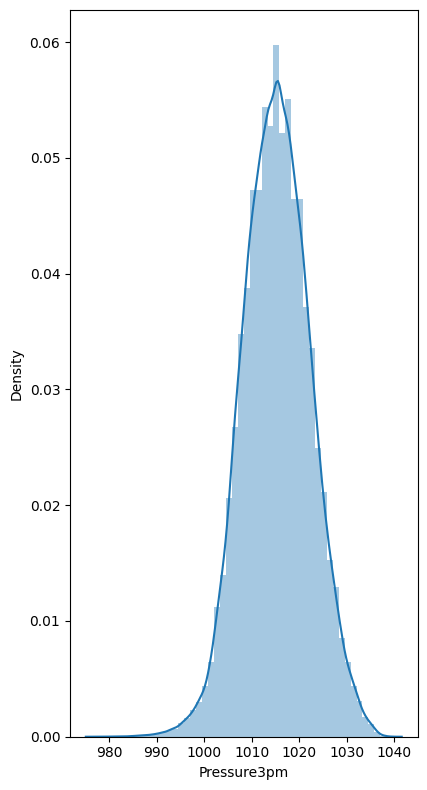

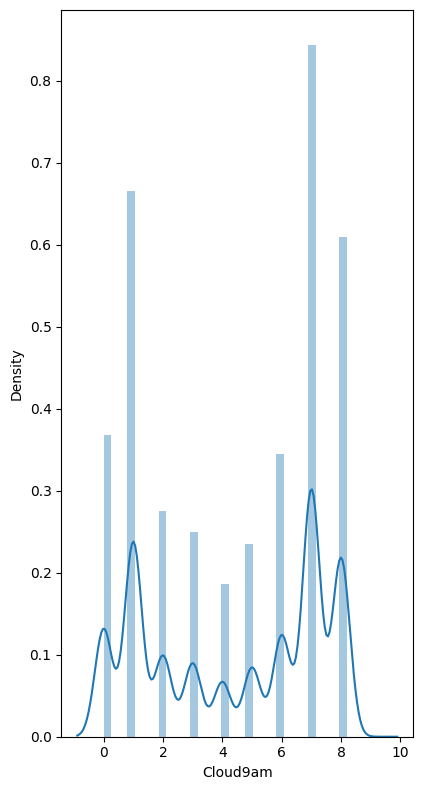

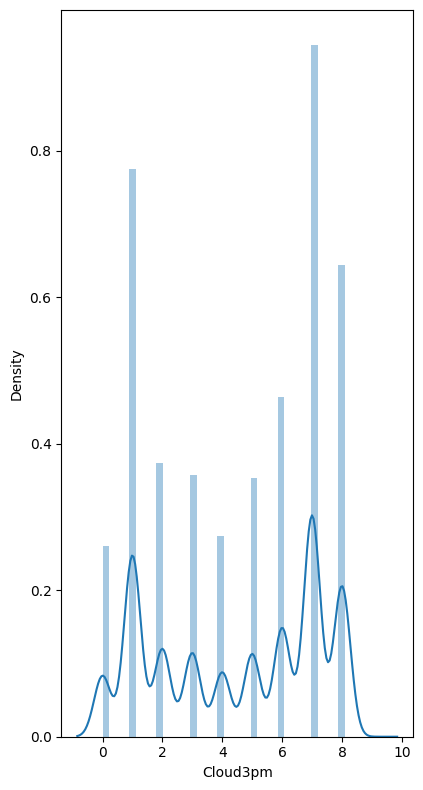

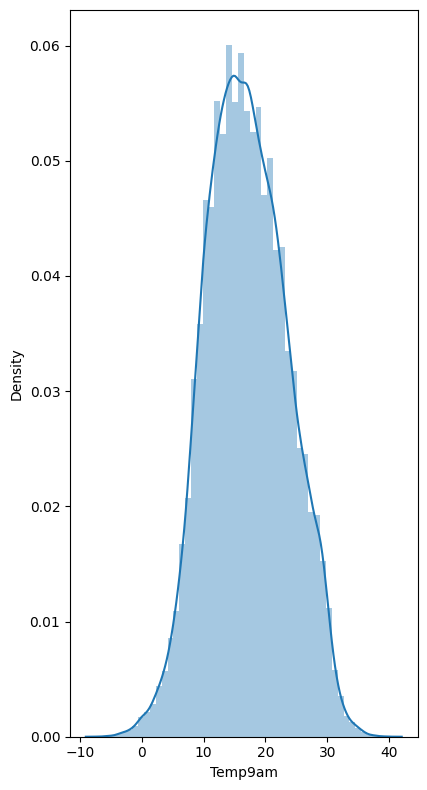

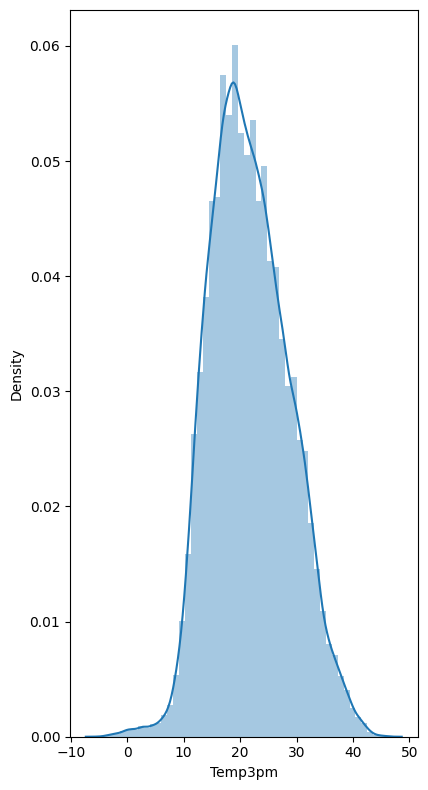

In [9]:
#plotting distribution of numeric columns
for col in weather_df[num_cols]:
    f = plt.figure(figsize=(8,8))
    ax = f.add_subplot(1,2,2)
    sns.distplot(weather_df[col])
    plt.tight_layout()
    plt.show()

In [10]:
weather_df[num_cols].isnull().sum()

,0
MinTemp,468
MaxTemp,307
Rainfall,0
Evaporation,59694
Sunshine,66805
WindGustSpeed,9105
WindSpeed9am,1055
WindSpeed3pm,2531
Humidity9am,1517
Humidity3pm,3501


In [11]:
#percentage of missing value
(weather_df[num_cols].isnull().sum() / len(weather_df)) * 100

,0
MinTemp,0.332417
MaxTemp,0.218060
Rainfall,0.000000
Evaporation,42.400222
Sunshine,47.451114
WindGustSpeed,6.467216
WindSpeed9am,0.749359
WindSpeed3pm,1.797751
Humidity9am,1.077514
Humidity3pm,2.486735


# Preprocessing

In [12]:
df = weather_df.copy()

In [14]:
# Imputation would be done by mean[] as their missing percentage is under 10% and have more of normal distribution
from sklearn.impute import SimpleImputer
si_mean = SimpleImputer(strategy='mean')
si_mean.fit(df[['MinTemp', 'MaxTemp' , 'Humidity3pm', 'Pressure9am', 'Pressure3pm' , 'Temp9am', 'Temp3pm']])
df[['MinTemp', 'MaxTemp' , 'Humidity3pm',
   'Pressure9am', 'Pressure3pm' , 'Temp9am','Temp3pm']] = si_mean.transform(df[['MinTemp', 'MaxTemp' , 'Humidity3pm', 'Pressure9am',
                                                                                         'Pressure3pm' , 'Temp9am', 'Temp3pm']])

In [15]:
# mean imputation for skewed distribution
si_median = SimpleImputer(strategy='median')
df[['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am']] = si_median.fit_transform(df[[ 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am']])

In [16]:
# High Number of Values is empty and the distribution also not normal will use KNNImputer
from sklearn.impute import KNNImputer
ki = KNNImputer(n_neighbors = 3)
df.Evaporation = ki.fit_transform(df[['Evaporation']])

In [17]:
df.Sunshine = ki.fit_transform(df[['Sunshine']])

In [18]:
df.Cloud9am = ki.fit_transform(df[['Cloud9am']])

In [19]:
df.Cloud3pm = ki.fit_transform(df[['Cloud3pm']])

<Axes: xlabel='RainTomorrow', ylabel='Count'>

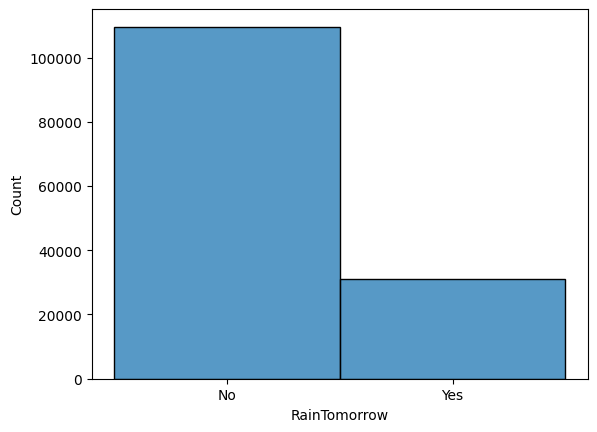

In [20]:
sns.histplot(x='RainTomorrow', data=df)

In [21]:
df.RainTomorrow.value_counts() / len(df) * 100

,count
RainTomorrow,
No,77.838153
Yes,22.161847


# Feature Engineering

In [22]:
# extracting Year Month Day from Date column
df.Date = pd.to_datetime(df.Date)
df['Year'] = df.Date.dt.year
df['Month'] = df.Date.dt.month
df['Day'] = df.Date.dt.day

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140787 entries, 0 to 145458
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           140787 non-null  datetime64[ns]
 1   Location       140787 non-null  object        
 2   MinTemp        140787 non-null  float64       
 3   MaxTemp        140787 non-null  float64       
 4   Rainfall       140787 non-null  float64       
 5   Evaporation    140787 non-null  float64       
 6   Sunshine       140787 non-null  float64       
 7   WindGustDir    131624 non-null  object        
 8   WindGustSpeed  140787 non-null  float64       
 9   WindDir9am     131127 non-null  object        
 10  WindDir3pm     137117 non-null  object        
 11  WindSpeed9am   140787 non-null  float64       
 12  WindSpeed3pm   140787 non-null  float64       
 13  Humidity9am    140787 non-null  float64       
 14  Humidity3pm    140787 non-null  float64       
 15  Press

In [24]:
# Updating numeric columns list as new columns are made
num_cols = df.select_dtypes(np.number).columns.to_list()

In [25]:
#names of object type columns
cat_cols = df.select_dtypes('object').columns.to_list()

In [26]:
cat_cols

['Location',
 'WindGustDir',
 'WindDir9am',
 'WindDir3pm',
 'RainToday',
 'RainTomorrow']

In [27]:
num_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'Year',
 'Month',
 'Day']

In [28]:
#removing unwanted Column name
cat_cols.remove('RainTomorrow')
cat_cols

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [65]:
#splitting data
from sklearn.model_selection import train_test_split
trainX, testX, trainY, testY = train_test_split(df.drop('RainTomorrow', axis=1), df['RainTomorrow'], test_size=.20, random_state=42, stratify =df['RainTomorrow'])

# Scaling Numeric Columns

In [66]:
from sklearn.preprocessing import MinMaxScaler , OneHotEncoder

In [67]:
scaler = MinMaxScaler()

In [68]:
scaler.fit(trainX[num_cols])

MinMaxScaler()

In [69]:
trainX[num_cols] = scaler.transform(trainX[num_cols])
testX[num_cols] = scaler.transform(testX[num_cols])

# One Hot Encoding

In [70]:
trainX[cat_cols].isna().sum()

,0
Location,0
WindGustDir,7334
WindDir9am,7712
WindDir3pm,2931
RainToday,0


In [71]:
testX[cat_cols].isna().sum()

,0
Location,0
WindGustDir,1829
WindDir9am,1948
WindDir3pm,739
RainToday,0


In [72]:
trainX[cat_cols] = trainX[cat_cols].fillna('Unknown')
testX[cat_cols] = testX[cat_cols].fillna('Unknown')

In [73]:
trainX[cat_cols].isna().sum()

,0
Location,0
WindGustDir,0
WindDir9am,0
WindDir3pm,0
RainToday,0


In [75]:
testX[cat_cols].isna().sum()

,0
Location,0
WindGustDir,0
WindDir9am,0
WindDir3pm,0
RainToday,0


In [76]:
encoder = OneHotEncoder()
encoder.fit(trainX[cat_cols])

OneHotEncoder()

In [77]:
#Name of encoded columns
encoded_cols = list(encoder.get_feature_names_out())
print(encoded_cols)

['Location_Adelaide', 'Location_Albany', 'Location_Albury', 'Location_AliceSprings', 'Location_BadgerysCreek', 'Location_Ballarat', 'Location_Bendigo', 'Location_Brisbane', 'Location_Cairns', 'Location_Canberra', 'Location_Cobar', 'Location_CoffsHarbour', 'Location_Dartmoor', 'Location_Darwin', 'Location_GoldCoast', 'Location_Hobart', 'Location_Katherine', 'Location_Launceston', 'Location_Melbourne', 'Location_MelbourneAirport', 'Location_Mildura', 'Location_Moree', 'Location_MountGambier', 'Location_MountGinini', 'Location_Newcastle', 'Location_Nhil', 'Location_NorahHead', 'Location_NorfolkIsland', 'Location_Nuriootpa', 'Location_PearceRAAF', 'Location_Penrith', 'Location_Perth', 'Location_PerthAirport', 'Location_Portland', 'Location_Richmond', 'Location_Sale', 'Location_SalmonGums', 'Location_Sydney', 'Location_SydneyAirport', 'Location_Townsville', 'Location_Tuggeranong', 'Location_Uluru', 'Location_WaggaWagga', 'Location_Walpole', 'Location_Watsonia', 'Location_Williamtown', 'Loca

In [81]:
encoded_trainX = encoder.transform(trainX[cat_cols])
encoded_data_train = pd.DataFrame(encoded_trainX.toarray(), columns=encoded_cols)

encoded_testX = encoder.transform(testX[cat_cols])
encoded_data_test = pd.DataFrame(encoded_testX.toarray(), columns=encoded_cols)

encoded_data_train.head()

,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_Unknown,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_No,RainToday_Yes
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [79]:
trainX.isnull().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0


In [82]:
print("training data shape:", trainX.shape)
print('shape of train encoded data:', encoded_data_train.shape)

print('test data shape:', testY.shape)
print('shape of test encoded data:', encoded_data_test.shape)

training data shape: (112629, 25)
shape of train encoded data: (112629, 102)
test data shape: (28158,)
shape of test encoded data: (28158, 102)


# Concating Data


In [83]:
trainX.reset_index(drop=True, inplace=True)
testX.reset_index(drop=True, inplace=True)

encoded_data_train.reset_index(drop=True, inplace=True)
encoded_data_test.reset_index(drop=True, inplace=True)

trainX = pd.concat([trainX[num_cols], encoded_data_train], axis=1)
testX = pd.concat([testX[num_cols], encoded_data_test], axis=1)

trainX.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_Unknown,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_No,RainToday_Yes
0,0.791563,0.871456,0.000000,0.037741,0.533604,0.294574,0.146154,0.068966,0.42,0.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.486352,0.325142,0.003808,0.017931,0.000000,0.255814,0.146154,0.080460,0.91,0.95,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.339950,0.406427,0.004897,0.037741,0.533604,0.255814,0.169231,0.172414,0.98,0.99,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.481390,0.376181,0.007073,0.015172,0.000000,0.170543,0.046154,0.172414,0.88,0.81,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.434243,0.446125,0.034276,0.037741,0.533604,0.341085,0.030769,0.103448,1.00,0.39,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


# Modelling

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [85]:
param_dist = {
    'C': uniform(0.001, 10),               # Regularization strength, from 0.001 to 10
    'solver': ['liblinear', 'newton-cg', 'saga'],  # Solvers
    'max_iter': randint(100, 1000),         # Number of iterations, between 100 and 1000
    'penalty': ['l2', 'l1', None],  # Penalty types
    'tol': uniform(1e-5, 1e-2),             # Tolerance for stopping criteria
    'class_weight': ['balanced'],     # Class weights
}

model = LogisticRegression()

In [86]:
random_search = RandomizedSearchCV(model, param_dist, n_iter=25, cv=3, scoring='f1', random_state=42, n_jobs=-1)

In [87]:
random_search.fit(trainX,trainY)

RandomizedSearchCV(cv=3, estimator=LogisticRegression(), n_iter=25, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7eb7d36bf150>,
                                        'class_weight': ['balanced'],
                                        'max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7eb7d36bd3d0>,
                                        'penalty': ['l2', 'l1', None],
                                        'solver': ['liblinear', 'newton-cg',
                                                   'saga'],
                                        'tol': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7eb7d36bce90>},
                   random_state=42, scoring='f1')

In [88]:
yhat = random_search.predict(testX)
y_prob = random_search.predict_proba(testX)

# Evaluating

In [89]:
from sklearn.metrics import confusion_matrix , classification_report, roc_curve, f1_score

In [91]:
print("f1 score for test data:", f1_score(testY,yhat, pos_label='Yes'))
print(classification_report(testY, yhat))

f1 score for test data: 0.6227106227106227
              precision    recall  f1-score   support

          No       0.93      0.80      0.86     21918
         Yes       0.52      0.78      0.62      6240

    accuracy                           0.79     28158
   macro avg       0.72      0.79      0.74     28158
weighted avg       0.84      0.79      0.80     28158



In [92]:
fpr,tpr,thresholds = roc_curve(testY, y_prob[:,1], pos_label='Yes')

In [93]:
#finding best threshold value
best_id = np.argmax(tpr - fpr)
best_thresh = thresholds[best_id]
print(best_thresh)

0.4888306185739855


In [94]:
yhat_new = np.where(y_prob[:,1] > best_thresh, 'Yes', 'No')

In [95]:
print("New f1 score after changing threshold value:", f1_score(testY,yhat_new, pos_label='Yes'))
print(classification_report(testY, yhat))

New f1 score after changing threshold value: 0.6221291714249461
              precision    recall  f1-score   support

          No       0.93      0.80      0.86     21918
         Yes       0.52      0.78      0.62      6240

    accuracy                           0.79     28158
   macro avg       0.72      0.79      0.74     28158
weighted avg       0.84      0.79      0.80     28158



Text(50.722222222222214, 0.5, 'Predictions')

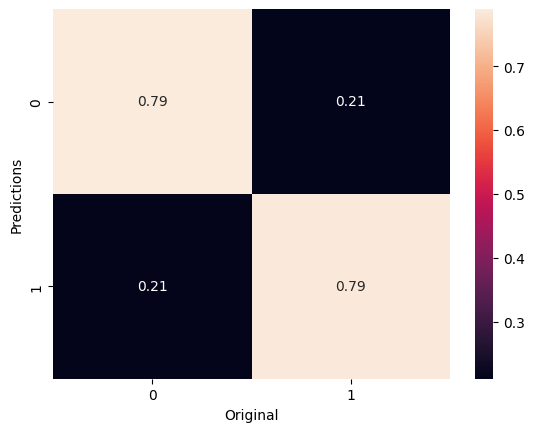

In [96]:
confuse = confusion_matrix(testY, yhat_new, normalize='true')
sns.heatmap(confuse,  annot=True)
plt.xlabel('Original')
plt.ylabel('Predictions')